<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/02-credit-risk/credit_risk_EVT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

한글 폰트 설정.

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ['checking_account','duration','credit_history','purpose','credit_amount',
           'savings','employment','installment_rate','personal_status','other_debtors',
           'residence_since','property','age','other_installment','housing',
           'existing_credits','job','num_dependents','telephone','foreign_worker','target']

df_credit = pd.read_csv(url, sep=' ', header=None, names=columns)
df_credit['target'] = df_credit['target'].map({1:0, 2:1})

df_encoded = pd.get_dummies(df_credit, columns=[
    'checking_account','credit_history','purpose','savings','employment',
    'personal_status','other_debtors','property','other_installment',
    'housing','job','telephone','foreign_worker'
], drop_first=True)

print(f"전체 대출자 수: {len(df_credit)}명, 부도율: {df_credit['target'].mean()*100:.2f}%")

전체 대출자 수: 1000명, 부도율: 30.00%


신용 데이터 불러오기 및 전처리.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
pd_pred = model.predict_proba(X_test)[:, 1]

print(f"PD 예측 완료. 검증 데이터 {len(X_test)}명")

PD 예측 완료. 검증 데이터 300명


학습/검증 분리 및 PD 모델 학습.

In [5]:
df_ecl = X_test.copy()
df_ecl['PD'] = pd_pred
df_ecl['EAD'] = df_credit.loc[X_test.index, 'credit_amount']
df_ecl['duration_months'] = df_credit.loc[X_test.index, 'duration']

LGD = 0.45
df_ecl['LGD'] = LGD

STAGE_THRESHOLD = 0.20
df_ecl['stage'] = np.where(df_ecl['PD'] >= STAGE_THRESHOLD, 'Stage 2', 'Stage 1')
df_ecl['lifetime_PD'] = 1 - (1 - df_ecl['PD']) ** (df_ecl['duration_months'] / 12)

df_ecl['ECL'] = np.where(
    df_ecl['stage'] == 'Stage 1',
    df_ecl['PD'] * df_ecl['LGD'] * df_ecl['EAD'],
    df_ecl['lifetime_PD'] * df_ecl['LGD'] * df_ecl['EAD']
)

print(df_ecl['stage'].value_counts())
print(f"\n전체 포트폴리오 총 기대손실(ECL): {df_ecl['ECL'].sum():,.0f}")

stage
Stage 2    166
Stage 1    134
Name: count, dtype: int64

전체 포트폴리오 총 기대손실(ECL): 225,325


ECL 계산. (Stage 분류 포함)

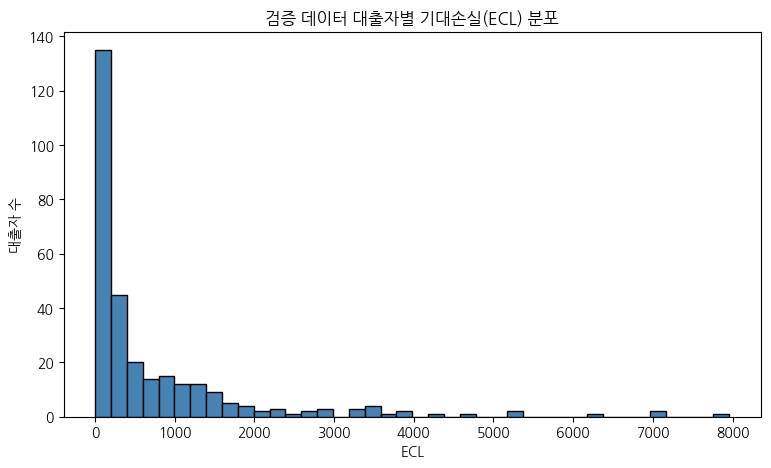

ECL 평균: 751.1
ECL 중앙값: 258.4
ECL 최대값: 7958.7


In [6]:
plt.figure(figsize=(9,5))
plt.hist(df_ecl['ECL'], bins=40, color='steelblue', edgecolor='black')
plt.title('검증 데이터 대출자별 기대손실(ECL) 분포')
plt.xlabel('ECL')
plt.ylabel('대출자 수')
plt.show()

print(f"ECL 평균: {df_ecl['ECL'].mean():.1f}")
print(f"ECL 중앙값: {df_ecl['ECL'].median():.1f}")
print(f"ECL 최대값: {df_ecl['ECL'].max():.1f}")

ECL 분포 확인.

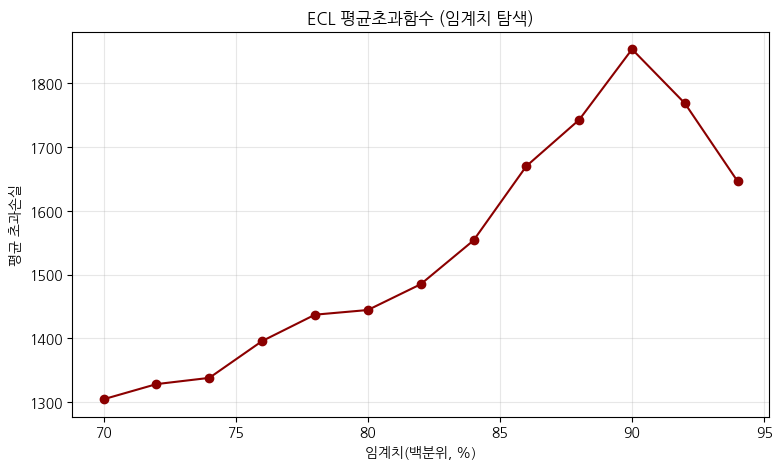

In [7]:
ecl_losses = df_ecl['ECL'].values
percentile_grid = np.arange(70, 95, 2)
mean_excess_ecl = []

for p in percentile_grid:
    u = np.percentile(ecl_losses, p)
    exc = ecl_losses[ecl_losses > u] - u
    mean_excess_ecl.append(exc.mean())

plt.figure(figsize=(9,5))
plt.plot(percentile_grid, mean_excess_ecl, marker='o', color='darkred')
plt.xlabel('임계치(백분위, %)')
plt.ylabel('평균 초과손실')
plt.title('ECL 평균초과함수 (임계치 탐색)')
plt.grid(alpha=0.3)
plt.show()

임계치 탐색. (평균초과함수)

In [8]:
from scipy.stats import genpareto

threshold_ecl = np.percentile(ecl_losses, 85)
exceedances_ecl = ecl_losses[ecl_losses > threshold_ecl] - threshold_ecl

print(f"임계치: {threshold_ecl:.1f}")
print(f"극단치 개수: {len(exceedances_ecl)}개 / 전체 {len(ecl_losses)}개")

shape_c, loc_c, scale_c = genpareto.fit(exceedances_ecl, floc=0)
print(f"GPD 추정 모수: shape(xi)={shape_c:.4f}, scale(beta)={scale_c:.4f}")

임계치: 1407.8
극단치 개수: 45개 / 전체 300개
GPD 추정 모수: shape(xi)=-0.0050, scale(beta)=1640.2579


GPD 적합.

In [9]:
total_ecl = df_ecl['ECL'].sum()
extreme_ecl = df_ecl[df_ecl['ECL'] > threshold_ecl]['ECL'].sum()
extreme_count = (df_ecl['ECL'] > threshold_ecl).sum()

print(f"전체 대출자 수: {len(df_ecl)}명")
print(f"임계치 초과 대출자 수: {extreme_count}명 ({extreme_count/len(df_ecl)*100:.1f}%)")
print(f"이들이 차지하는 전체 ECL 비중: {extreme_ecl/total_ecl*100:.1f}%")

전체 대출자 수: 300명
임계치 초과 대출자 수: 45명 (15.0%)
이들이 차지하는 전체 ECL 비중: 60.7%


손실 집중도 정량화.

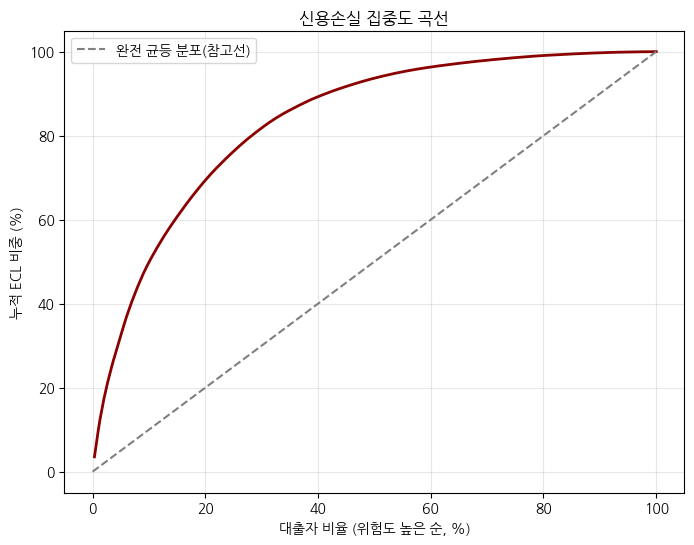

In [10]:
sorted_ecl = np.sort(df_ecl['ECL'].values)[::-1]
cumulative_ecl = np.cumsum(sorted_ecl) / sorted_ecl.sum()
borrower_pct = np.arange(1, len(sorted_ecl)+1) / len(sorted_ecl)

plt.figure(figsize=(8,6))
plt.plot(borrower_pct*100, cumulative_ecl*100, color='darkred', linewidth=2)
plt.plot([0,100], [0,100], linestyle='--', color='gray', label='완전 균등 분포(참고선)')
plt.xlabel('대출자 비율 (위험도 높은 순, %)')
plt.ylabel('누적 ECL 비중 (%)')
plt.title('신용손실 집중도 곡선')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

손실 집중도 곡선 시각화.

In [11]:
threshold_ecl_90 = np.percentile(ecl_losses, 90)
exceedances_ecl_90 = ecl_losses[ecl_losses > threshold_ecl_90] - threshold_ecl_90

print(f"임계치: {threshold_ecl_90:.1f}")
print(f"극단치 개수: {len(exceedances_ecl_90)}개 / 전체 {len(ecl_losses)}개")

shape_c_90, loc_c_90, scale_c_90 = genpareto.fit(exceedances_ecl_90, floc=0)
print(f"GPD 추정 모수: shape(xi)={shape_c_90:.4f}, scale(beta)={scale_c_90:.4f}")

임계치: 1891.0
극단치 개수: 30개 / 전체 300개
GPD 추정 모수: shape(xi)=-0.2488, scale(beta)=2330.9008


임계치 90%로 GPD 재적합.

In [12]:
extreme_ecl_90 = df_ecl[df_ecl['ECL'] > threshold_ecl_90]['ECL'].sum()
extreme_count_90 = (df_ecl['ECL'] > threshold_ecl_90).sum()

print(f"임계치 초과 대출자 수: {extreme_count_90}명 ({extreme_count_90/len(df_ecl)*100:.1f}%)")
print(f"이들이 차지하는 전체 ECL 비중: {extreme_ecl_90/total_ecl*100:.1f}%")

임계치 초과 대출자 수: 30명 (10.0%)
이들이 차지하는 전체 ECL 비중: 49.9%


90% 임계치 기준 집중도.